# Final Project - YOLO Road Object Detection

This notebook is the primary model from the proposal. It fine-tunes pretrained YOLO weights on the six selected BDD100K classes, evaluates validation and held-out test data, displays training plots and predictions, and saves the best model.

## Metric used for the 80% target

Object detection does not have one classification-style accuracy because every image can contain many boxes. The project therefore treats **F1 at IoU 0.50** as the requested accuracy-like acceptance metric and also reports the proposal's standard precision, recall, mAP@50, and mAP@50:95. The notebook measures the target; it does not manufacture or guarantee it before the dataset is trained.

In [1]:
from pathlib import Path
import json, random, sys, time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Image as DisplayImage, display
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'Project: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__} | device: {DEVICE}')

Project: C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project
PyTorch: 2.10.0+cpu | device: cpu


## Run profile

`cpu_quick` is deliberately small enough to prove the full workflow on a CPU. `cpu_practical` uses more data and time. `accuracy` is the final full-data experiment and is best run on a GPU. The two-stage schedule first freezes early layers, then fine-tunes the complete detector.

In [2]:
RUN_MODE = 'cpu_quick'  # cpu_quick | cpu_practical | accuracy
TARGET_F1 = 0.80

PROFILES = {
    'cpu_quick': dict(model='yolo11n.pt', imgsz=64, batch=2, fraction=1.0,
                      frozen_epochs=1, finetune_epochs=1, freeze=10, workers=0,
                      patience=5, device='cpu', cache=False, multi_scale=False),
    'cpu_practical': dict(model='yolo11s.pt', imgsz=768, batch=2, fraction=0.10,
                          frozen_epochs=15, finetune_epochs=10, freeze=10, workers=0,
                          patience=8, device='cpu', cache='disk', multi_scale=False),
    'accuracy': dict(model='yolo11m.pt', imgsz=960, batch=-1, fraction=1.0,
                     frozen_epochs=20, finetune_epochs=80, freeze=10, workers=8,
                     patience=20, device=DEVICE, cache='disk', multi_scale=True),
}
cfg = PROFILES[RUN_MODE]
RUN_ROOT = PROJECT_ROOT / 'tmp' / 'executed_notebooks' / 'yolo'
RUN_NAME = f'bdd100k_{RUN_MODE}'
DATA_YAML = PROJECT_ROOT / 'tmp' / 'smoke_yolo' / 'data.yaml'
cfg

{'model': 'yolo11n.pt',
 'imgsz': 64,
 'batch': 2,
 'fraction': 1.0,
 'frozen_epochs': 1,
 'finetune_epochs': 1,
 'freeze': 10,
 'workers': 0,
 'patience': 5,
 'device': 'cpu',
 'cache': False,
 'multi_scale': False}

## Verify the converted dataset

Run `scripts/prepare_bdd100k.ps1` first. It creates train, validation, and a deterministic labeled test holdout. The official BDD100K test annotations are not public, so this local holdout is necessary for measured test metrics.

In [3]:
assert DATA_YAML.exists(), f'Missing {DATA_YAML}. Convert BDD100K before training.'
data_config = yaml.safe_load(DATA_YAML.read_text(encoding='utf-8'))
dataset_root = Path(data_config['path'])
class_names = list(data_config['names'].values()) if isinstance(data_config['names'], dict) else data_config['names']

split_rows = []
for split in ('train', 'val', 'test'):
    image_dir = dataset_root / 'images' / split
    label_dir = dataset_root / 'labels' / split
    split_rows.append({
        'split': split,
        'images': len(list(image_dir.glob('*'))) if image_dir.exists() else 0,
        'label_files': len(list(label_dir.glob('*.txt'))) if label_dir.exists() else 0,
    })
split_table = pd.DataFrame(split_rows)
display(split_table)
assert split_table.set_index('split').loc[['train', 'val', 'test'], 'images'].min() > 0

,split,images,label_files
0,train,6,6
1,val,4,4
2,test,1,1


,class,training_boxes
0,car,1
1,bus,1
2,truck,1
3,pedestrian,1
4,traffic light,1
5,traffic sign,1


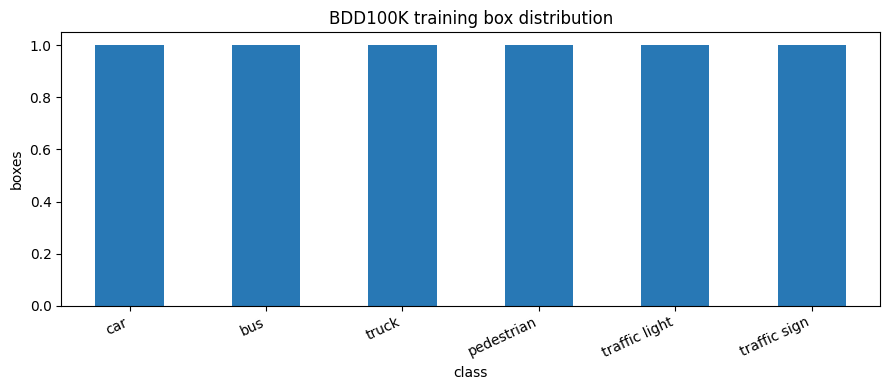

In [4]:
class_counts = np.zeros(len(class_names), dtype=np.int64)
for label_path in (dataset_root / 'labels' / 'train').glob('*.txt'):
    for line in label_path.read_text(encoding='utf-8').splitlines():
        if line.strip():
            class_counts[int(line.split()[0])] += 1
distribution = pd.DataFrame({'class': class_names, 'training_boxes': class_counts})
display(distribution)
ax = distribution.plot.bar(x='class', y='training_boxes', figsize=(9, 4), legend=False, color='#2878b5')
ax.set_title('BDD100K training box distribution')
ax.set_ylabel('boxes')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Stage 1 - fast transfer learning with a frozen backbone

In [5]:
model = YOLO(cfg['model'])
stage1 = model.train(
    data=str(DATA_YAML), epochs=cfg['frozen_epochs'], imgsz=cfg['imgsz'], batch=cfg['batch'],
    device=cfg['device'], workers=cfg['workers'], project=str(RUN_ROOT), name=f'{RUN_NAME}_frozen',
    fraction=cfg['fraction'], freeze=cfg['freeze'], pretrained=True, optimizer='AdamW',
    lr0=0.002, lrf=0.10, cos_lr=True, warmup_epochs=2.0, patience=cfg['patience'],
    mosaic=0.8, mixup=0.05, hsv_h=0.015, hsv_s=0.65, hsv_v=0.35,
    translate=0.08, scale=0.40, fliplr=0.50, close_mosaic=3,
    multi_scale=cfg['multi_scale'], amp=cfg['device'] != 'cpu', cache=cfg['cache'],
    seed=SEED, deterministic=True, plots=True, save=True, exist_ok=True,
)
stage1_best = Path(stage1.save_dir) / 'weights' / 'best.pt'
assert stage1_best.exists()
stage1_best

New https://pypi.org/project/ultralytics/8.4.107 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)


engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\smoke_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.65, hsv_v=0.35, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=bdd100k_cpu_quick_frozen, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience

Overriding model.yaml nc=80 with nc=6



                   from  n    params  module                                       arguments                     


...

                 truck          1          1          0          0          0          0


         traffic light          1          1          0          0          0          0


Speed: 0.1ms preprocess, 8.4ms inference, 0.0ms loss, 0.3ms postprocess per image


Results saved to C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\executed_notebooks\yolo\bdd100k_cpu_quick_frozen


WindowsPath('C:/Users/vipra/OneDrive/Documents/GitHub/ECGR-5106-Intro-To-Deep-Learning/Final_Project/tmp/executed_notebooks/yolo/bdd100k_cpu_quick_frozen/weights/best.pt')

## Stage 2 - unfreeze and fine-tune

This lower-learning-rate stage adapts the pretrained visual features to BDD100K while reducing catastrophic forgetting.

In [6]:
model = YOLO(str(stage1_best))
stage2 = model.train(
    data=str(DATA_YAML), epochs=cfg['finetune_epochs'], imgsz=cfg['imgsz'], batch=cfg['batch'],
    device=cfg['device'], workers=cfg['workers'], project=str(RUN_ROOT), name=f'{RUN_NAME}_finetuned',
    fraction=cfg['fraction'], freeze=0, optimizer='AdamW', lr0=0.0008, lrf=0.05,
    cos_lr=True, warmup_epochs=1.0, patience=cfg['patience'], mosaic=0.5, mixup=0.02,
    hsv_h=0.015, hsv_s=0.55, hsv_v=0.30, translate=0.06, scale=0.30, fliplr=0.50,
    close_mosaic=3, multi_scale=cfg['multi_scale'], amp=cfg['device'] != 'cpu',
    cache=cfg['cache'], seed=SEED, deterministic=True, plots=True, save=True, exist_ok=True,
)
BEST_WEIGHTS = Path(stage2.save_dir) / 'weights' / 'best.pt'
assert BEST_WEIGHTS.exists()
best_model = YOLO(str(BEST_WEIGHTS))
BEST_WEIGHTS

New https://pypi.org/project/ultralytics/8.4.107 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)


engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\smoke_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.55, hsv_v=0.3, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.02, mode=train, model=C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\executed_notebooks\yolo\bdd100k_cpu_quick_frozen\weights\best.pt, momentum=0.937, mosaic=


                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 truck          1          1          0          0          0          0


         traffic light          1          1          0          0          0          0


Speed: 0.1ms preprocess, 7.5ms inference, 0.0ms loss, 0.3ms postprocess per image


Results saved to C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\executed_notebooks\yolo\bdd100k_cpu_quick_finetuned


WindowsPath('C:/Users/vipra/OneDrive/Documents/GitHub/ECGR-5106-Intro-To-Deep-Learning/Final_Project/tmp/executed_notebooks/yolo/bdd100k_cpu_quick_finetuned/weights/best.pt')

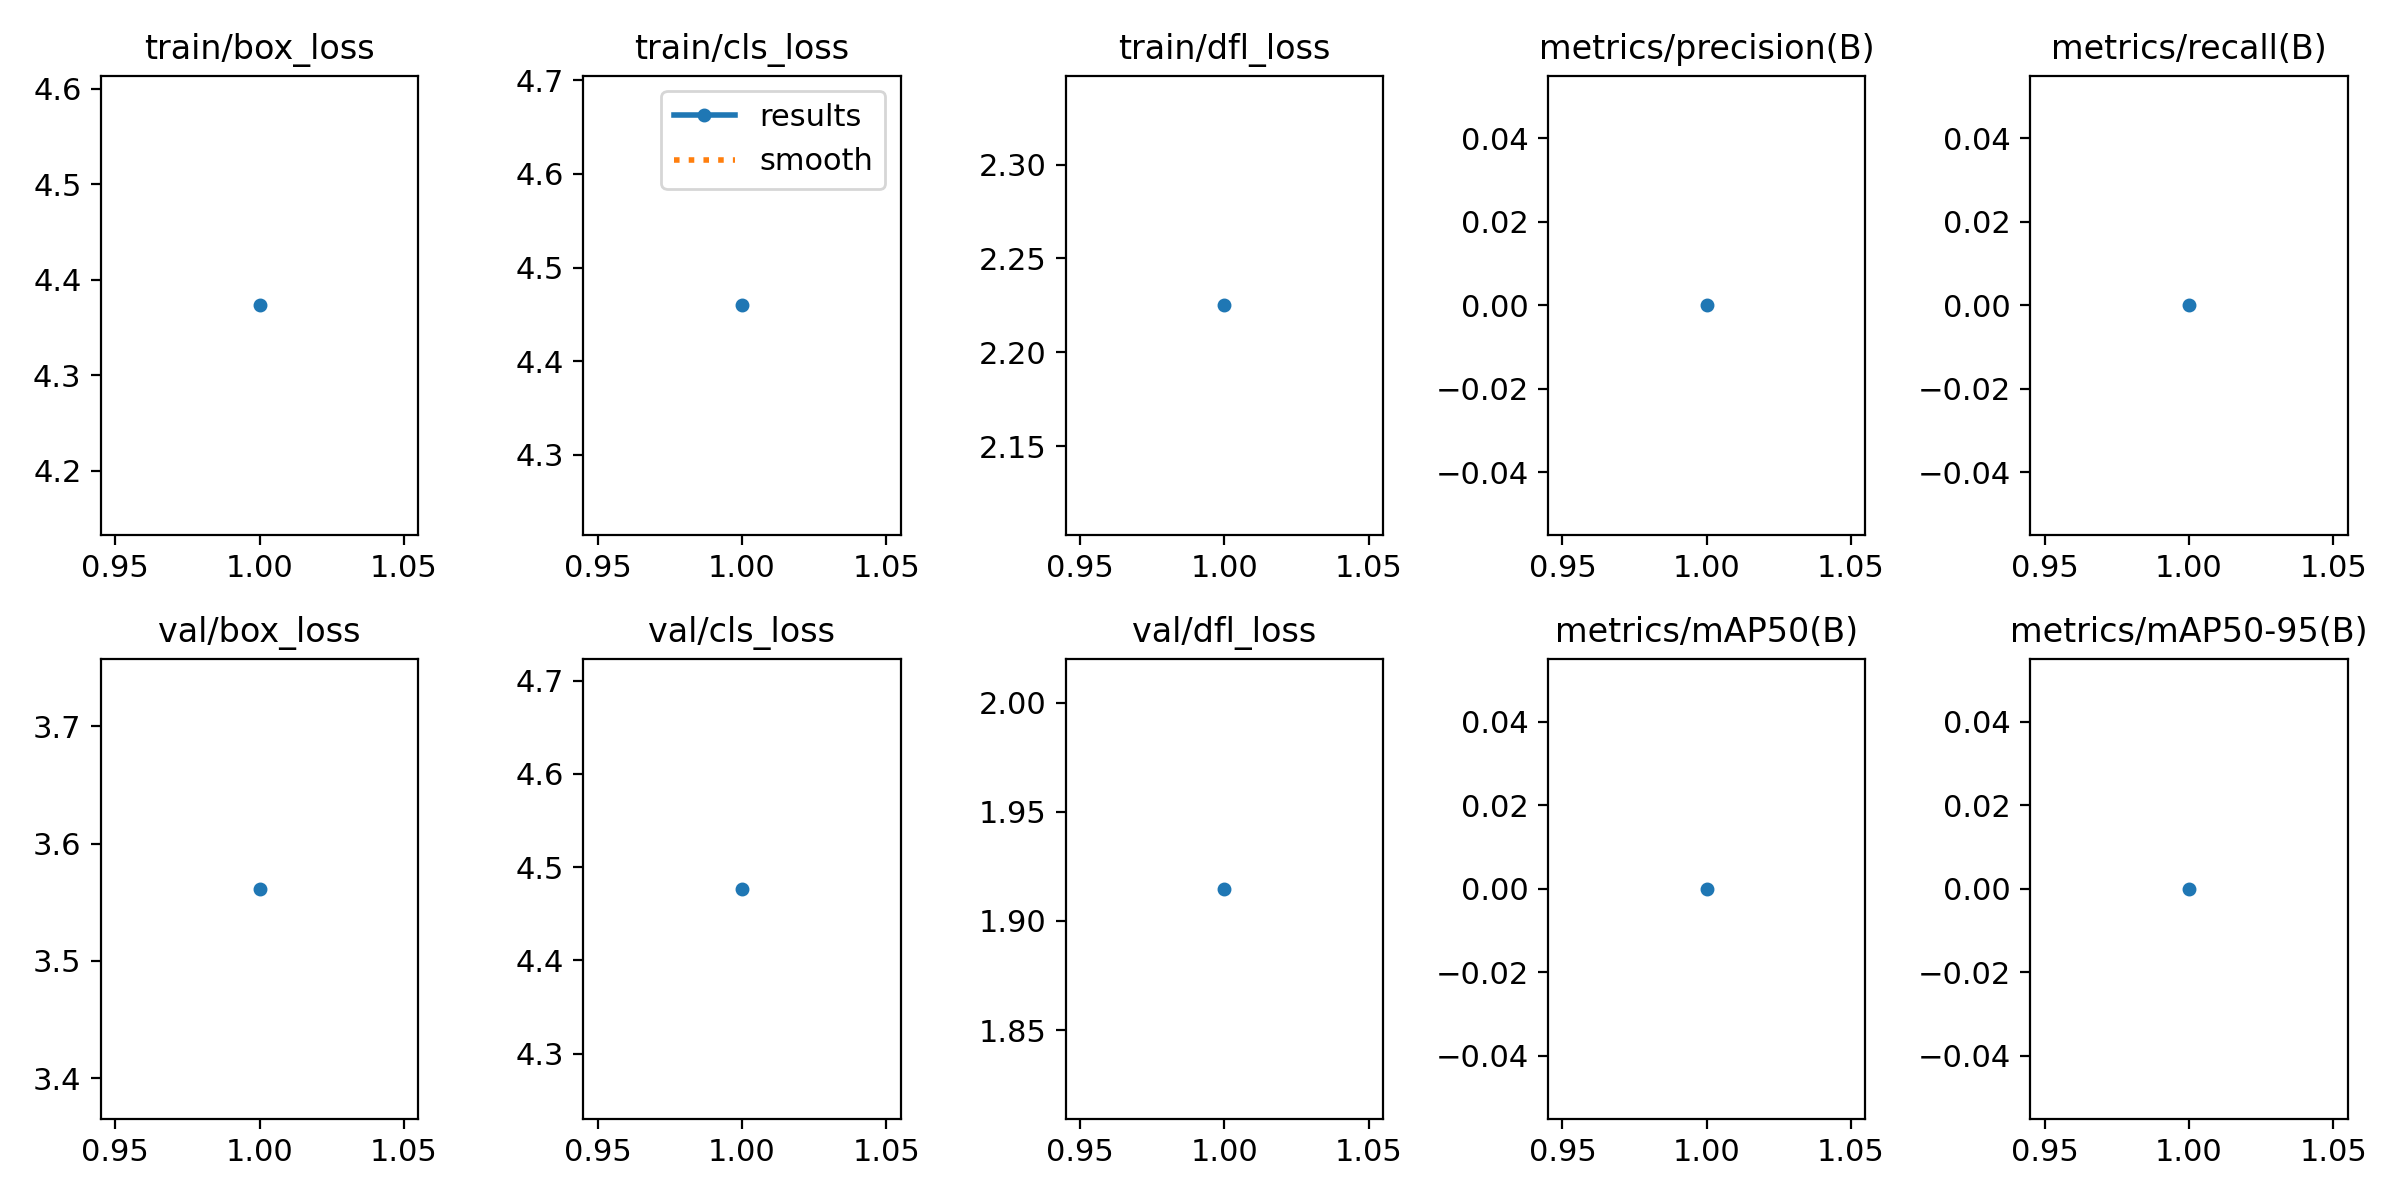

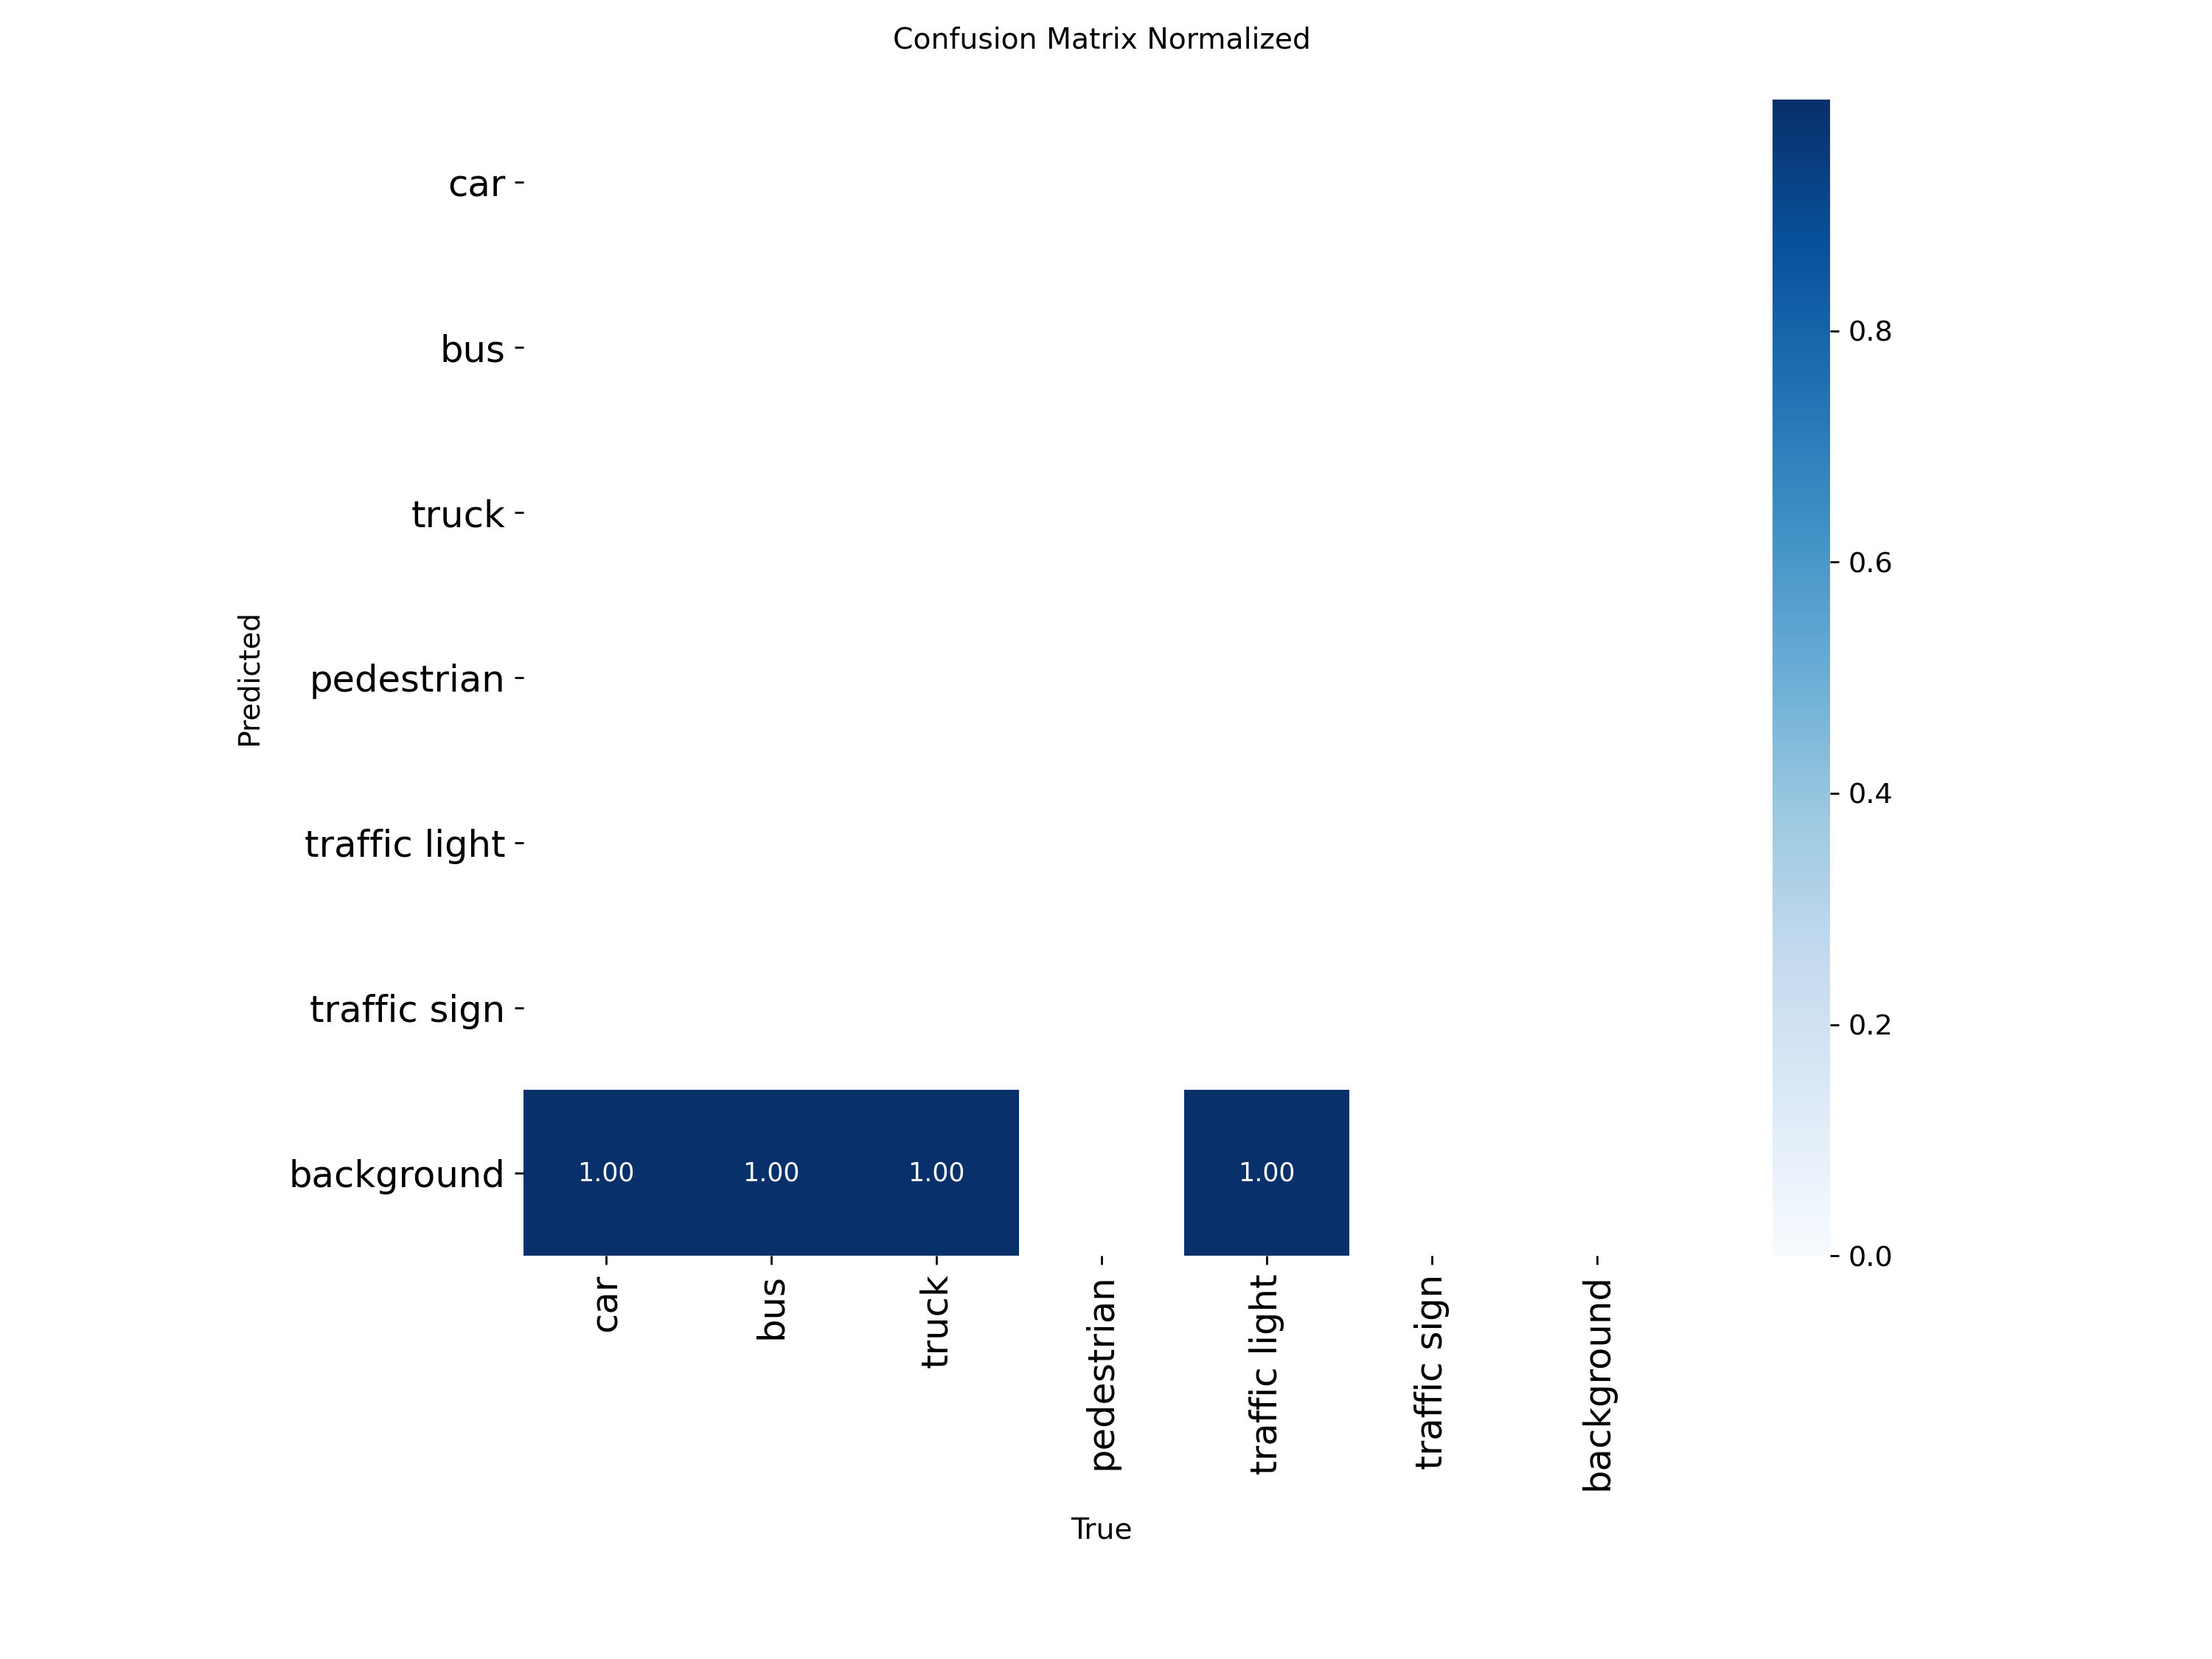

In [7]:
for filename in ('results.png', 'PR_curve.png', 'confusion_matrix_normalized.png'):
    plot_path = Path(stage2.save_dir) / filename
    if plot_path.exists():
        display(DisplayImage(filename=str(plot_path)))

## Validation and held-out test evaluation

In [8]:
def summarize_metrics(split, metrics):
    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)
    f1 = 2 * precision * recall / max(1e-12, precision + recall)
    return {'split': split, 'precision': precision, 'recall': recall, 'f1': f1,
            'mAP50': float(metrics.box.map50), 'mAP50_95': float(metrics.box.map)}

val_metrics = best_model.val(data=str(DATA_YAML), split='val', imgsz=cfg['imgsz'], batch=cfg['batch'],
                             device=cfg['device'], workers=cfg['workers'], conf=0.001,
                             plots=True, project=str(RUN_ROOT), name=f'{RUN_NAME}_val', verbose=False)
test_metrics = best_model.val(data=str(DATA_YAML), split='test', imgsz=cfg['imgsz'], batch=cfg['batch'],
                              device=cfg['device'], workers=cfg['workers'], conf=0.001,
                              plots=True, project=str(RUN_ROOT), name=f'{RUN_NAME}_test', verbose=False)
summary = pd.DataFrame([summarize_metrics('validation', val_metrics), summarize_metrics('test', test_metrics)])
display(summary.style.format({column: '{:.3f}' for column in summary.columns if column != 'split'}))

Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)


YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 7.02.3 MB/s, size: 0.8 KB)


val: Scanning C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\smoke_yolo\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.7Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 26.0it/s 0.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 28.4it/s 0.0s

                   all          1          1          0          0          0          0


Speed: 0.1ms preprocess, 18.4ms inference, 0.0ms loss, 0.5ms postprocess per image


Results saved to C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\executed_notebooks\yolo\bdd100k_cpu_quick_test2


,split,precision,recall,f1,mAP50,mAP50_95
0,validation,0.000,0.000,0.000,0.000,0.000
1,test,0.000,0.000,0.000,0.000,0.000


In [9]:
def per_class_table(metrics):
    rows = []
    metric_position = {int(class_id): position for position, class_id in enumerate(metrics.ap_class_index)}
    for class_id, name in best_model.names.items():
        position = metric_position.get(class_id)
        precision = float(metrics.box.p[position]) if position is not None else 0.0
        recall = float(metrics.box.r[position]) if position is not None else 0.0
        rows.append({'class': name, 'precision': precision, 'recall': recall,
                     'f1': 2 * precision * recall / max(1e-12, precision + recall),
                     'mAP50': float(metrics.box.ap50[position]) if position is not None else 0.0,
                     'mAP50_95': float(metrics.box.maps[class_id])})
    return pd.DataFrame(rows)

display(per_class_table(val_metrics).style.format({c: '{:.3f}' for c in ['precision', 'recall', 'f1', 'mAP50', 'mAP50_95']}))
display(per_class_table(test_metrics).style.format({c: '{:.3f}' for c in ['precision', 'recall', 'f1', 'mAP50', 'mAP50_95']}))

,class,precision,recall,f1,mAP50,mAP50_95
0,car,0.000,0.000,0.000,0.000,0.000
1,bus,0.000,0.000,0.000,0.000,0.000
2,truck,0.000,0.000,0.000,0.000,0.000
3,pedestrian,0.000,0.000,0.000,0.000,0.000
4,traffic light,0.000,0.000,0.000,0.000,0.000
5,traffic sign,0.000,0.000,0.000,0.000,0.000


,class,precision,recall,f1,mAP50,mAP50_95
0,car,0.000,0.000,0.000,0.000,0.000
1,bus,0.000,0.000,0.000,0.000,0.000
2,truck,0.000,0.000,0.000,0.000,0.000
3,pedestrian,0.000,0.000,0.000,0.000,0.000
4,traffic light,0.000,0.000,0.000,0.000,0.000
5,traffic sign,0.000,0.000,0.000,0.000,0.000


In [10]:
acceptance = summary[['split', 'f1']].copy()
acceptance['target'] = TARGET_F1
acceptance['passed'] = acceptance['f1'] >= TARGET_F1
display(acceptance)
if not acceptance['passed'].all():
    print('The measured 0.80 F1 target has not yet been met. Use cpu_practical or accuracy, inspect weak classes, and retrain.')
else:
    print('The 0.80 validation/test F1 target is met.')

,split,f1,target,passed
0,validation,0.0,0.8,False
1,test,0.0,0.8,False


The measured 0.80 F1 target has not yet been met. Use cpu_practical or accuracy, inspect weak classes, and retrain.


## Qualitative predictions and failure cases

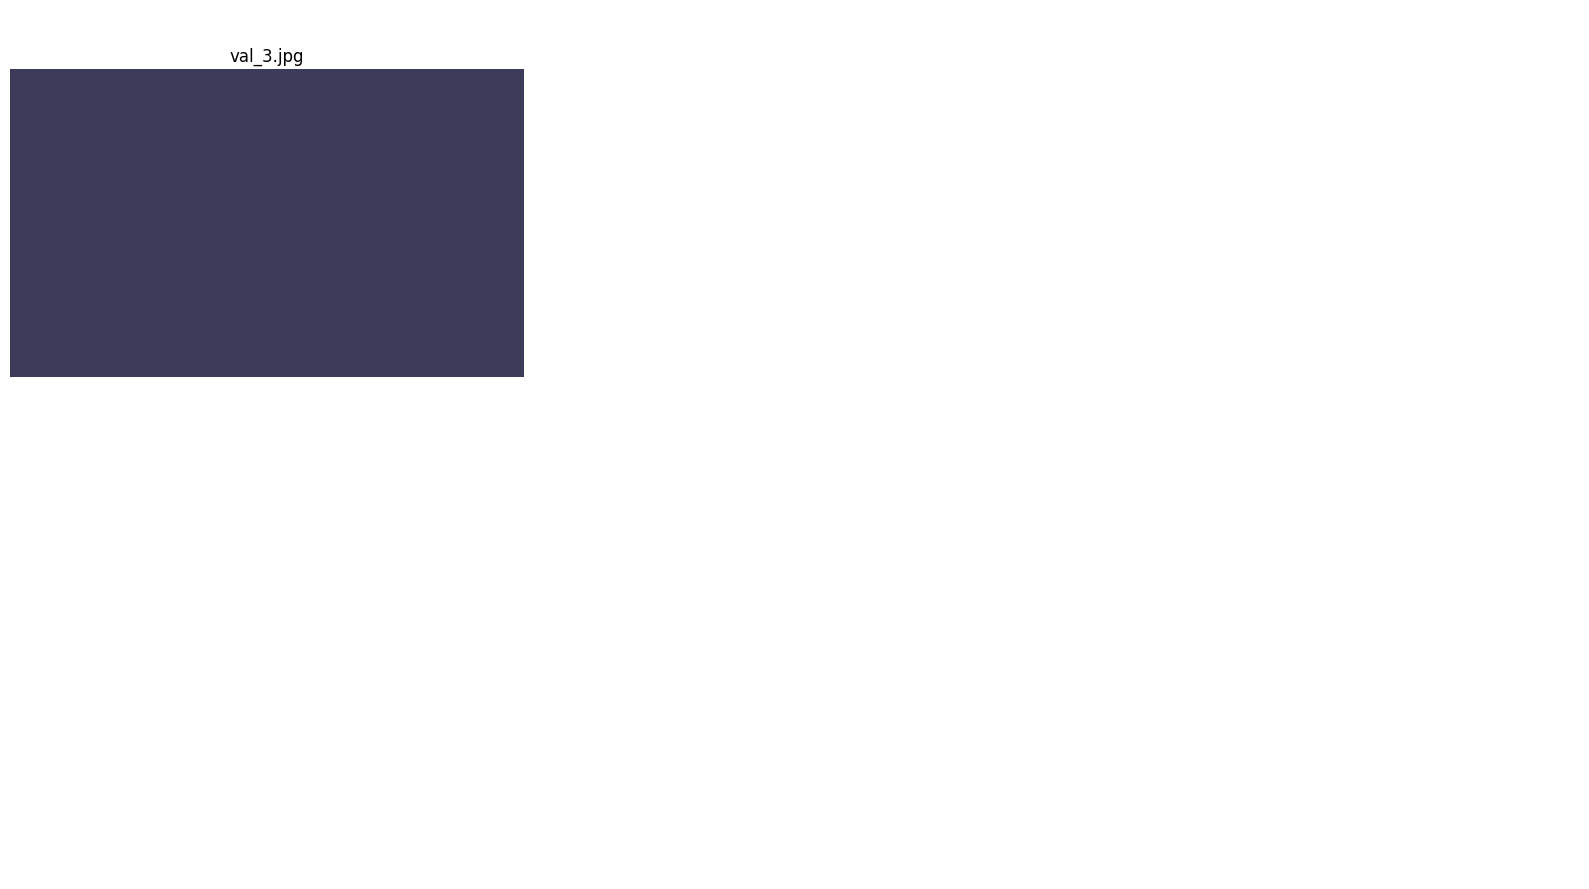

In [11]:
test_images = sorted((dataset_root / 'images' / 'test').glob('*'))
sample_images = random.Random(SEED).sample(test_images, min(6, len(test_images)))
prediction_results = best_model.predict(sample_images, imgsz=cfg['imgsz'], conf=0.25,
                                        device=cfg['device'], verbose=False)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, result, image_path in zip(axes.flat, prediction_results, sample_images):
    axis.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    axis.set_title(Path(image_path).name)
    axis.axis('off')
for axis in axes.flat[len(prediction_results):]: axis.axis('off')
plt.tight_layout()
plt.show()

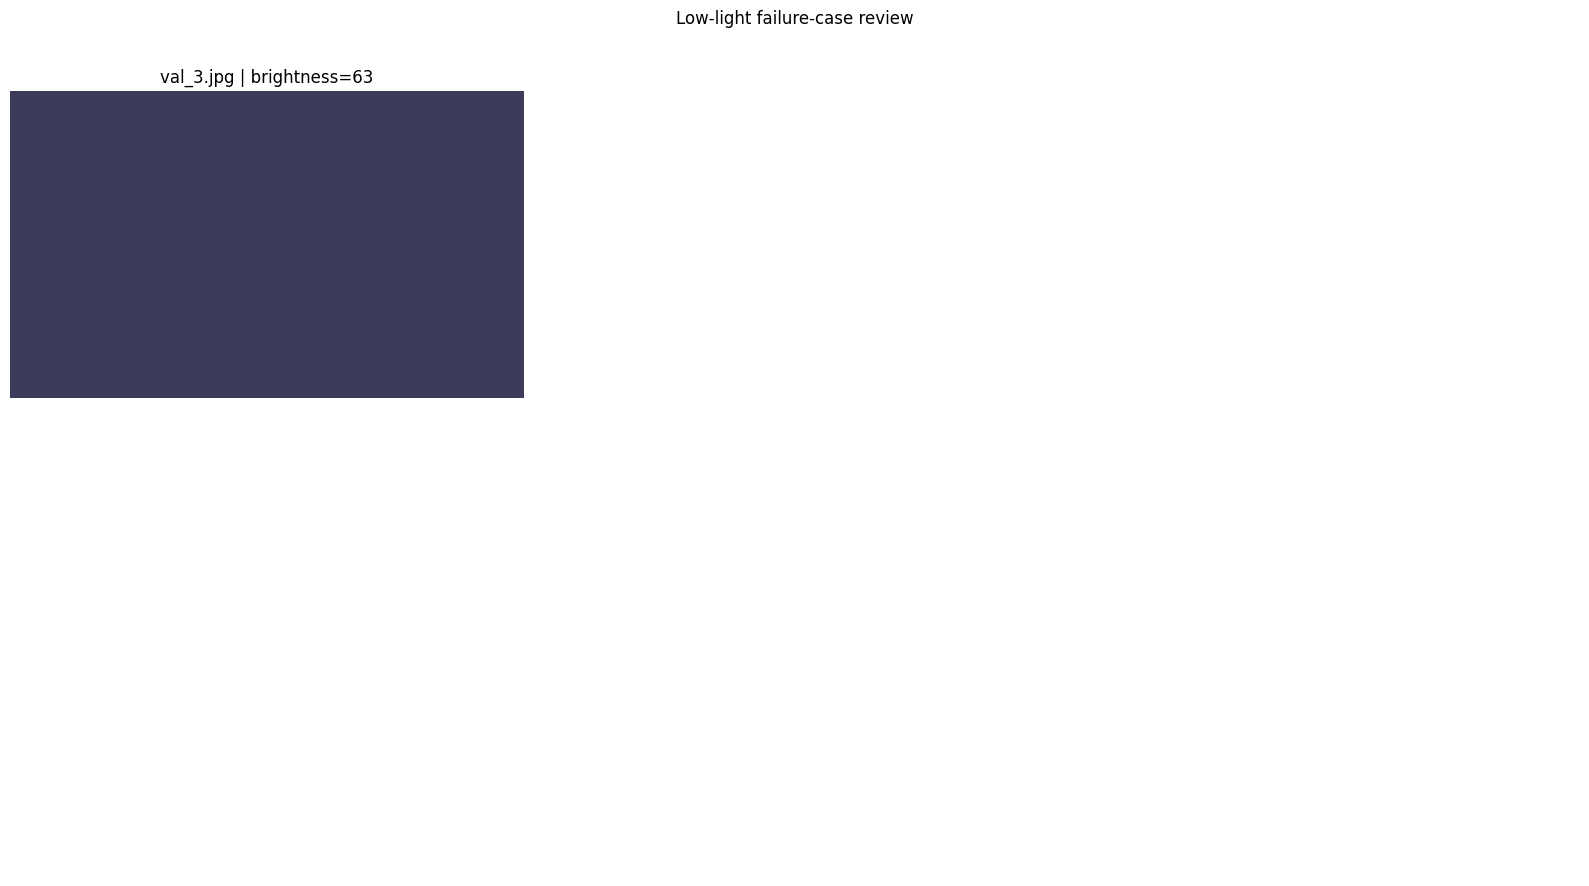

In [12]:
def brightness(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return float(image.mean()) if image is not None else 255.0

dark_images = sorted(test_images, key=brightness)[:min(6, len(test_images))]
dark_results = best_model.predict(dark_images, imgsz=cfg['imgsz'], conf=0.20,
                                  device=cfg['device'], verbose=False)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, result, image_path in zip(axes.flat, dark_results, dark_images):
    axis.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    axis.set_title(f'{Path(image_path).name} | brightness={brightness(Path(image_path)):.0f}')
    axis.axis('off')
for axis in axes.flat[len(dark_results):]: axis.axis('off')
plt.suptitle('Low-light failure-case review')
plt.tight_layout()
plt.show()

## CPU inference benchmark and saved report

In [13]:
benchmark_images = test_images[:min(25, len(test_images))]
started = time.perf_counter()
_ = best_model.predict(benchmark_images, imgsz=cfg['imgsz'], conf=0.25, device=cfg['device'], verbose=False)
elapsed = time.perf_counter() - started
fps = len(benchmark_images) / max(elapsed, 1e-9)
print(f'{len(benchmark_images)} images in {elapsed:.2f}s = {fps:.2f} FPS on {cfg["device"]}')

report = {'run_mode': RUN_MODE, 'weights': str(BEST_WEIGHTS), 'target_f1': TARGET_F1,
          'inference_fps': fps, 'metrics': summary.to_dict(orient='records')}
report_path = Path(stage2.save_dir) / 'final_evaluation.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')
summary.to_csv(Path(stage2.save_dir) / 'final_metrics.csv', index=False)
print(f'Saved report: {report_path}')

1 images in 0.01s = 110.95 FPS on cpu
Saved report: C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\tmp\executed_notebooks\yolo\bdd100k_cpu_quick_finetuned\final_evaluation.json
